In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm  # PyTorch Image Models (ResNeSt için şart)
import os
import time
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import seaborn as sns
import pandas as pd
import numpy as np

# Uyarıları gizlemek için (isteğe bağlı)
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import torch

# --- KONFIGURASYON ---
# ResNeSt50 Modeli (timm kutuphanesindeki adi)
MODEL_NAME = 'resnest50d'

# Deney adi dosya ve klasor isimleri buna gore olacak
EXPERIMENT_NAME = "ResNeSt50_Baseline_MediumLarge_Run2"

# Hiperparametreler
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 3e-4
NUM_CLASSES = 8
IMAGE_SIZE = 224
DROPOUT_RATE = 0.25

# Duzenlilestirme ve egitim kararliligi
WEIGHT_DECAY = 5e-5
LABEL_SMOOTHING = 0.03
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 0
USE_CLASS_WEIGHTED_LOSS = False
LOSS_NAME = "cross_entropy"
FOCAL_GAMMA = 2.0

# Notebook + Windows icin daha stabil DataLoader ayari
NUM_WORKERS = 0 if os.name == 'nt' else 4

# Proje kok yolunu calisma dizininden bagimsiz bul
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd

# Dosya yollari
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")

# Calistirma etiketleri (hiperparametrelere gore otomatik dosya isimlendirme)
dropout_tag = f"dropout{int(round(DROPOUT_RATE * 10)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace(".", "p")
RUN_TAG = f"{dropout_tag}_{ls_tag}_{wd_tag}_bs{BATCH_SIZE}_ep{EPOCHS}_{lr_tag}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"

# Sonuclarin kaydedilecegi yer
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# En iyi model dosya yolu
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_model_{MODEL_NAME}_{RUN_TAG}.pth")

# Cihazi GPU'ya zorla
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA/GPU bulunamadi. GPU'da calismak icin NVIDIA surucusu, CUDA destekli PyTorch ve dogru kernel ortami gerekli."
    )

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU Sayisi: {torch.cuda.device_count()}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Label Smoothing: {LABEL_SMOOTHING}")
print(f"Warmup Epochs: {WARMUP_EPOCHS}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE} (0 = kapalI)")
print(f"Image Size: {IMAGE_SIZE}")
print(f"Loss: {LOSS_NAME}, gamma={FOCAL_GAMMA}")

Cihaz: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
GPU Sayisi: 1
Model: resnest50d
Kayit Yeri: ../models/pytorch/ResNeSt50_Baseline_MediumLarge_Run2


In [30]:
# ImageNet Normalize Değerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Veri Dönüşümleri
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}

# Datasetleri Oluştur
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Sinif dagilimina gore class weight hesapla
train_targets = np.array(image_datasets['train'].targets)
class_sample_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
class_weight_values = class_sample_counts.sum() / (NUM_CLASSES * np.clip(class_sample_counts, 1, None))
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values, dtype=torch.float32)

# DataLoaderları Oluştur
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                             shuffle=(x=='train'), num_workers=NUM_WORKERS, pin_memory=True)
               for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Sınıflar: {class_names}")
print(f"Eğitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")
print(f"Sinif sayimlari (train): {class_sample_counts.tolist()}")
print(f"Class weights aktif: {USE_CLASS_WEIGHTED_LOSS}")
print(f"Image Size: {IMAGE_SIZE}")

Sınıflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Eğitim Verisi: 5592
Validasyon Verisi: 1200


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm

# Bu hücre tek başına çalıştırılırsa, eksik ayarları varsayılanlarla tamamla.
MODEL_NAME = globals().get("MODEL_NAME", "resnest50d")
NUM_CLASSES = globals().get("NUM_CLASSES", 8)
DROPOUT_RATE = globals().get("DROPOUT_RATE", 0.25)
LEARNING_RATE = globals().get("LEARNING_RATE", 3e-4)
LABEL_SMOOTHING = globals().get("LABEL_SMOOTHING", 0.03)
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 5e-5)
WARMUP_EPOCHS = globals().get("WARMUP_EPOCHS", 3)
EPOCHS = globals().get("EPOCHS", 30)
USE_CLASS_WEIGHTED_LOSS = globals().get("USE_CLASS_WEIGHTED_LOSS", False)
LOSS_NAME = globals().get("LOSS_NAME", "cross_entropy")
FOCAL_GAMMA = globals().get("FOCAL_GAMMA", 2.0)
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")
    # pretrained=True ile ImageNet ağırlıklarını alıyoruz
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES, drop_rate=DROPOUT_RATE)
    return model

model = create_model()
model = model.to(DEVICE)

# Kayıp Fonksiyonu ve Optimizer
loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE) if USE_CLASS_WEIGHTED_LOSS else None
if LOSS_NAME == "focal":
    criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=loss_weight)
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Warmup + Cosine plan
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))
    progress = (epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print("Model GPU'ya yüklendi ve eğitime hazır.")
print(f"AdamW + weight_decay={WEIGHT_DECAY}, label_smoothing={LABEL_SMOOTHING}")
print(f"Loss fonksiyonu: {LOSS_NAME}")

Model indiriliyor: resnest50d...
Model GPU'ya yüklendi ve eğitime hazır.


In [32]:
import os
import time
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = ["dataloaders", "dataset_sizes", "OUTPUT_DIR", "DEVICE", "BEST_MODEL_PATH", "EARLY_STOPPING_PATIENCE"]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigürasyon hucrelerini calistirin."
        )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Batch Döngüsü
            for batch_idx, (inputs, labels) in enumerate(dataloaders[phase], start=1):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Geçmişi Kaydet
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # En iyi modeli kaydet (validasyon kaybina gore)
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    epochs_without_improvement = 0
                    torch.save(model.state_dict(), BEST_MODEL_PATH)
                    print(f"En Iyi Model (val loss: {best_val_loss:.4f}) -> {BEST_MODEL_PATH}")
                else:
                    epochs_without_improvement += 1
                    if EARLY_STOPPING_PATIENCE > 0:
                        print(f"Val loss iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")
                    else:
                        print(f"Val loss iyilesmedi: {epochs_without_improvement} epoch")

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Guncel LR: {current_lr:.8f}")

        if EARLY_STOPPING_PATIENCE > 0 and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi.")
            break

    time_elapsed = time.time() - since
    print(f'\nEğitim Tamamlandı: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En iyi Validasyon Doğruluğu: {best_acc:.4f}')
    print(f'En iyi Validasyon Kaybi: {best_val_loss:.4f}')

    # En iyi ağırlıkları geri yükle
    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    return model, history

In [33]:
# --- BAŞLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )

num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Epoch 1/50
----------
train Loss: 0.6642 Acc: 0.7405
val Loss: 0.4059 Acc: 0.8492
En iyi Model! (0.8492) -> Kaydedildi.
Epoch 2/50
----------
train Loss: 0.4105 Acc: 0.8448
val Loss: 0.6248 Acc: 0.7958
Epoch 3/50
----------
train Loss: 0.3098 Acc: 0.8823
val Loss: 0.2905 Acc: 0.8750
En iyi Model! (0.8750) -> Kaydedildi.
Epoch 4/50
----------
train Loss: 0.2923 Acc: 0.8906
val Loss: 0.3851 Acc: 0.8558
Epoch 5/50
----------
train Loss: 0.2456 Acc: 0.9022
val Loss: 0.3738 Acc: 0.8792
En iyi Model! (0.8792) -> Kaydedildi.
Epoch 6/50
----------
train Loss: 0.2246 Acc: 0.9177
val Loss: 0.3922 Acc: 0.8550
Epoch 7/50
----------
train Loss: 0.1856 Acc: 0.9313
val Loss: 0.3195 Acc: 0.8875
En iyi Model! (0.8875) -> Kaydedildi.
Epoch 8/50
----------
train Loss: 0.2017 Acc: 0.9249
val Loss: 0.3205 Acc: 0.8917
En iyi Model! (0.8917) -> Kaydedildi.
Epoch 9/50
----------
train Loss: 0.1694 Acc: 0.9353
val Loss: 0.4759 Acc: 0.8442
Epoch 10/50
----------
train Loss: 0.0920 Acc: 0.9680
val Loss: 0.2497 A

KeyboardInterrupt: 

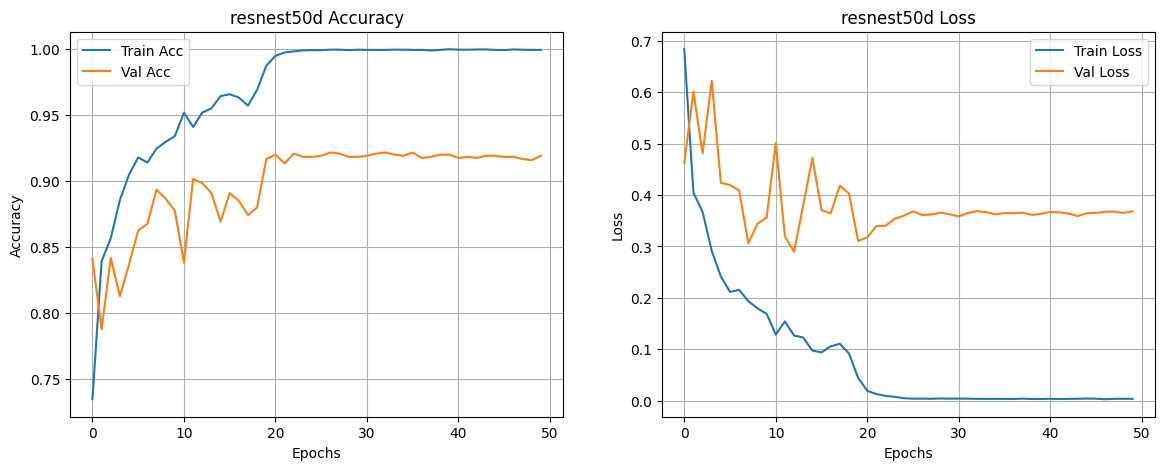

Grafikler kaydedildi: ..\outputs\ResNeSt50_Baseline_MediumLarge_Run1_training_graph.png


In [25]:
plt.figure(figsize=(14, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# outputs/<model>/plots klasorune kaydet
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')

plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")

In [ ]:
print("\nTEST SETI DEGERLENDIRMESI")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Classification Report (F1, Recall, Precision)
print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")

report_text = report + f"\nMacro F1: {macro_f1:.6f}\n" + "Class Recall:\n"
for class_name, rec in zip(class_names, class_recalls):
    report_text += f"{class_name}: {rec:.6f}\n"

os.makedirs(OUTPUT_DIR, exist_ok=True)
primary_report_path = os.path.join(OUTPUT_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
fallback_report_dir = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'reports')
fallback_report_path = os.path.join(fallback_report_dir, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')

report_path = primary_report_path
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report_text)
except (FileNotFoundError, OSError):
    os.makedirs(fallback_report_dir, exist_ok=True)
    report_path = fallback_report_path
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report_text)
    print("Uyari: Uzun yol nedeniyle rapor fallback klasorune kaydedildi.")
print(f"Classification report kaydedildi: {report_path}")

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")

In [ ]:
# --- ABLATION KARSILASTIRMA OZETI ---
ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

force_weighted_sampler = globals().get('FORCE_WEIGHTED_SAMPLER', False)
use_weighted_sampler = globals().get('USE_WEIGHTED_SAMPLER', False)

name_to_idx = {name: i for i, name in enumerate(class_names)}
pair_1_err = np.nan
pair_2_err = np.nan

if 'cm' in globals() and 'esophagitis' in name_to_idx and 'normal-z-line' in name_to_idx:
    i, j = name_to_idx['esophagitis'], name_to_idx['normal-z-line']
    pair_1_err = int(cm[i, j] + cm[j, i])

if 'cm' in globals() and 'dyed-lifted-polyps' in name_to_idx and 'dyed-resection-margins' in name_to_idx:
    i, j = name_to_idx['dyed-lifted-polyps'], name_to_idx['dyed-resection-margins']
    pair_2_err = int(cm[i, j] + cm[j, i])

current_row = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'force_weighted_sampler': force_weighted_sampler,
    'use_weighted_sampler': use_weighted_sampler,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() and history.get('val_acc') else np.nan,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() and history.get('val_loss') else np.nan,
    'test_macro_f1': float(macro_f1) if 'macro_f1' in globals() else np.nan,
    'pair_err_esophagitis_normal_z_line': pair_1_err,
    'pair_err_dyed_lifted_vs_resection': pair_2_err
}

if os.path.exists(ablation_csv_path):
    df_existing = pd.read_csv(ablation_csv_path)
else:
    df_existing = pd.DataFrame()

if not df_existing.empty and 'run_name' in df_existing.columns:
    df_existing = df_existing[df_existing['run_name'] != RUN_NAME].copy()

df_updated = pd.concat([df_existing, pd.DataFrame([current_row])], ignore_index=True)
df_updated.to_csv(ablation_csv_path, index=False)
print(f"Ablation CSV guncellendi: {ablation_csv_path}")

df = pd.read_csv(ablation_csv_path).copy()
if df.empty:
    raise ValueError('Ablation CSV bos.')

numeric_cols = [
    'best_val_acc',
    'best_val_loss',
    'test_macro_f1',
    'pair_err_esophagitis_normal_z_line',
    'pair_err_dyed_lifted_vs_resection'
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'pair_err_esophagitis_normal_z_line' in df.columns and 'pair_err_dyed_lifted_vs_resection' in df.columns:
    df['critical_pair_error_total'] = (
        df['pair_err_esophagitis_normal_z_line'].fillna(0) +
        df['pair_err_dyed_lifted_vs_resection'].fillna(0)
    )
else:
    df['critical_pair_error_total'] = np.nan

sort_cols = []
ascending = []
if 'test_macro_f1' in df.columns:
    sort_cols.append('test_macro_f1')
    ascending.append(False)
if 'critical_pair_error_total' in df.columns:
    sort_cols.append('critical_pair_error_total')
    ascending.append(True)
if 'best_val_loss' in df.columns:
    sort_cols.append('best_val_loss')
    ascending.append(True)

if sort_cols:
    ranked_df = df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
else:
    ranked_df = df.copy()

display_cols = [
    'run_name', 'run_tag', 'test_macro_f1', 'best_val_acc', 'best_val_loss',
    'pair_err_esophagitis_normal_z_line', 'pair_err_dyed_lifted_vs_resection',
    'critical_pair_error_total', 'force_weighted_sampler', 'use_weighted_sampler',
    'use_class_weighted_loss', 'learning_rate', 'weight_decay', 'dropout_rate', 'label_smoothing'
]
display_cols = [c for c in display_cols if c in ranked_df.columns]

print(f"Toplam kayit: {len(ranked_df)}")
print('\nEn iyi 5 kosu:')
display(ranked_df[display_cols].head(5))

best_run = ranked_df.iloc[0]
print('\nSecilen en iyi kosu:')
for c in display_cols:
    print(f"{c}: {best_run[c]}")

if 'critical_pair_error_total' in ranked_df.columns and 'test_macro_f1' in ranked_df.columns:
    print('\nYorum: test_macro_f1 yuksek ve kritik ikili hata dusuk olan kosular onceliklendirildi.')
